# Taller: demanda de pasajeros en estaciones de TransMilenio

**Pregunta:** ¿cuántas personas entran a una estación troncal en cada franja de 15 minutos, según la hora, el tipo de día y la estación?

**Datos de entrenamiento:** todas las estaciones de las zonas AutoNorte, Calle 26 y NQS Sur, de junio a agosto de 2026.
**Estaciones de estudio (donde se reportan los resultados):** Alcalá, Modelia y Terreros.

| Bloque | Contenido | Responsable |
|---|---|---|
| 0 | Configuración | |
| 1 | Fase 1: problema y base de datos | |
| 2 | Fase 2: exploración y preparación | |
| 3 | Fase 3: métodos y matriz de aplicabilidad | |
| 4 | Fase 4: comparación de finalistas | |
| 5 | Fase 5: insumos para los dos informes | |

## Bloque 0. Configuración

### 0.1 Solo en Colab: clonar el repositorio y traer los Excel desde Drive
En un computador local esta celda no hace nada. En Colab, cambien las tres líneas marcadas.

In [1]:
import sys, os
EN_COLAB = "google.colab" in sys.modules
if EN_COLAB:
    from getpass import getpass
    from google.colab import drive
    DUENO, REPO = "QueenR1014", "FlujoTransmilenio"        # cambiar
    if not os.path.exists(f"/content/{REPO}"):
        token = getpass("Token de GitHub: ")
        !git clone https://{token}@github.com/{DUENO}/{REPO}.git /content/{REPO}
        !git -C /content/{REPO} config user.name "Unttypicallteen"                # cambiar
        !git -C /content/{REPO} config user.email "sjorigua@gmail.com"   # cambiar
    drive.mount("/content/drive")
    !mkdir -p /content/{REPO}/data/raw
    !cp -n /content/drive/MyDrive/Datos_Taller_AAD/*.xlsx /content/{REPO}/data/raw/
    os.chdir(f"/content/{REPO}/notebooks")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cp: warning: behavior of -n is non-portable and may change in future; use --update=none instead


### 0.2 Librerías y parámetros
Todo lo que se puede cambiar está en esta celda.

In [2]:
from pathlib import Path
from datetime import datetime, timedelta
import re, warnings, zipfile, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse

from sklearn.base import BaseEstimator, RegressorMixin, TransformerMixin
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, SplineTransformer

SEED = 42
np.random.seed(SEED)
warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW, PROC, FIG = ROOT / "data" / "raw", ROOT / "data" / "processed", ROOT / "reports" / "figuras"
for p in (RAW, PROC, FIG):
    p.mkdir(parents=True, exist_ok=True)

# Zonas con las que se entrena (texto que debe aparecer en la columna Línea). None = todas.
ZONAS = ["AutoNorte", "Calle 26", "NQS Sur"]

# Estaciones de estudio: código -> nombre corto. Los resultados se reportan para estas.
ESTUDIO = {"02200": "Alcalá", "06001": "Modelia", "07504": "Terreros"}

# Festivos del periodo (confirmar con un calendario oficial)
FESTIVOS = pd.to_datetime(["2026-06-08", "2026-06-15", "2026-06-29",
                           "2026-07-20", "2026-08-07", "2026-08-17"])

URL_GTFS = "https://storage.googleapis.com/gtfs-estaticos/GTFS_20260712.zip"
DIAS_TEST = 21        # los últimos días del periodo se reservan como conjunto de prueba
N_FOLDS = 5           # validación cruzada por grupos de fecha
RECARGAR = False      # True = volver a leer los Excel aunque exista el archivo procesado

## Bloque 1. Fase 1: problema y base de datos

**Para redactar (entregable de una página):**

- **Origen:** TransMilenio S.A., "Validaciones mensuales del SITP por franja horaria", Datos Abiertos Bogotá. Enlace y fecha de descarga: _completar_.
- **Tamaño:** _completar con la salida de la celda 1.2 (registros crudos y registros para modelar)_.
- **Variable objetivo:** validaciones por estación, fecha y franja de 15 minutos.
- **Variables explicativas:** _completar con la celda 2.3_.
- **Por qué este problema y por qué estas zonas:** _completar_.

### 1.1 Funciones de carga
Cada Excel trae una fila por acceso y franja, y una columna por día. La función lo pasa a una fila por estación, fecha y franja.

In [3]:
def a_minutos(t):
    """Convierte el intervalo a minutos desde medianoche, venga como hora, texto o número."""
    if hasattr(t, "hour"):
        return t.hour * 60 + t.minute
    if isinstance(t, (pd.Timedelta, timedelta)):
        return int(t.total_seconds() // 60)
    if isinstance(t, (int, float)) and not pd.isna(t):
        return int(round(float(t) * 1440)) % 1440
    m = re.search(r"(\d{1,2}):(\d{2})", str(t))
    if not m:
        return np.nan
    h, mi = int(m.group(1)), int(m.group(2))
    s = str(t).lower()
    if "p" in s and h < 12: h += 12
    if "a" in s and h == 12: h = 0
    return h * 60 + mi

def cargar_mes(ruta):
    """Lee un Excel mensual de validaciones troncales y devuelve (tabla larga, registros crudos)."""
    bruto = pd.read_excel(ruta, sheet_name=0, header=None)
    fila = bruto.index[bruto.eq("Fase").any(axis=1)][0]            # fila del encabezado
    enc = bruto.loc[fila].tolist()
    c0 = enc.index("Fase")
    primera = next(h for h in enc if isinstance(h, (datetime, pd.Timestamp)))
    c_dia = enc.index(primera)
    c_tot = next((i for i, h in enumerate(enc) if isinstance(h, str) and "Total" in h), len(enc))
    fechas = [pd.Timestamp(primera) + timedelta(days=i) for i in range(c_tot - c_dia)]

    df = bruto.iloc[fila + 1:, c0:c_tot].copy()
    df.columns = ["fase", "linea", "estacion", "acceso", "intervalo"] + fechas
    df = df[df.fase.notna() & (df.fase != "Total general")]
    df = df[df.linea.astype(str).str.contains("Zona", na=False)]  # estaciones troncales (no rutas duales)
    crudos = len(df) * len(fechas)                                 # registros acceso x franja x día
    if ZONAS is not None:
        df = df[df.linea.str.contains("|".join(ZONAS))]
    df["codigo"] = df.estacion.str.extract(r"\((\d+)\)")[0]
    df["nombre"] = df.estacion.str.replace(r"^\(\d+\)\s*", "", regex=True)

    largo = df.melt(id_vars=["codigo", "nombre", "linea", "acceso", "intervalo"], value_vars=fechas,
                    var_name="fecha", value_name="validaciones")
    largo["validaciones"] = pd.to_numeric(largo.validaciones, errors="coerce").fillna(0)
    largo["franja_min"] = largo.intervalo.apply(a_minutos)
    if largo.franja_min.isna().any():
        print(f"  {Path(ruta).name[:40]}: {largo.franja_min.isna().sum()} registros sin hora legible, se descartan")
        largo = largo.dropna(subset=["franja_min"])
    largo["franja_min"] = largo.franja_min.astype(int)
    out = (largo.groupby(["codigo", "linea", "fecha", "franja_min"], as_index=False)
                .agg(validaciones=("validaciones", "sum"), accesos=("acceso", "nunique"),
                     nombre=("nombre", "first")))
    return out, crudos

### 1.2 Cargar todos los meses de `data/raw/`

In [4]:
archivo_proc = PROC / "validaciones_modelo.csv"
if archivo_proc.exists() and not RECARGAR:
    datos = pd.read_csv(archivo_proc, dtype={"codigo": str}, parse_dates=["fecha"])
    print("Leído de", archivo_proc.name)
else:
    partes, resumen = [], []
    for ruta in sorted(RAW.glob("*.xlsx")):
        tabla, crudos = cargar_mes(ruta)
        partes.append(tabla)
        resumen.append({"archivo": ruta.name[:60], "registros_crudos": crudos,
                        "registros_modelo": len(tabla), "estaciones": tabla.codigo.nunique(),
                        "desde": tabla.fecha.min().date(), "hasta": tabla.fecha.max().date()})
    assert partes, f"No hay archivos .xlsx en {RAW}"
    datos = pd.concat(partes, ignore_index=True).sort_values(["codigo", "fecha", "franja_min"])
    datos.to_csv(archivo_proc, index=False)
    resumen = pd.DataFrame(resumen)
    resumen.to_csv(PROC / "resumen_carga.csv", index=False)
    display(resumen)

nombres = datos.groupby("codigo").nombre.first().to_dict()
nombres.update(ESTUDIO)
datos["estacion"] = datos.codigo.map(nombres)
datos["estudio"] = datos.codigo.isin(ESTUDIO)
faltan = set(ESTUDIO) - set(datos.codigo)
if faltan:
    print("AVISO: estas estaciones de estudio no están en los datos:", faltan)
print("Registros para modelar:", len(datos), "| estaciones:", datos.codigo.nunique(),
      "| días:", datos.fecha.nunique(), "| de", datos.fecha.min().date(), "a", datos.fecha.max().date())
print("Registros de las estaciones de estudio:", int(datos.estudio.sum()))
display(datos.groupby("linea").agg(estaciones=("codigo", "nunique"), registros=("codigo", "size")))

Leído de validaciones_modelo.csv
Registros para modelar: 365118 | estaciones: 50 | días: 92 | de 2026-06-01 a 2026-08-31
Registros de las estaciones de estudio: 21731


,estaciones,registros
linea,,
(11) Zona K Calle 26,15,108624
(30) Zona G NQS Sur,17,126604
(33) Zona B AutoNorte,18,129890


### 1.3 Oferta programada y ubicación (GTFS)
Descarga el GTFS si no está en `data/raw/`. De ahí salen los buses y rutas programados por estación, tipo de día y franja, y la latitud y longitud de cada estación. Si la descarga falla, el notebook sigue sin esas variables.

In [5]:
ruta_gtfs = RAW / "gtfs.zip"
if not ruta_gtfs.exists():
    try:
        print("Descargando GTFS (unos 113 MB)...")
        urllib.request.urlretrieve(URL_GTFS, ruta_gtfs)
    except Exception as e:
        print("No se pudo descargar el GTFS:", e)

oferta, ubicacion = None, None
if ruta_gtfs.exists():
    z = zipfile.ZipFile(ruta_gtfs)
    stops = pd.read_csv(z.open("stops.txt"), dtype=str)
    trips = pd.read_csv(z.open("trips.txt"), dtype=str, usecols=["route_id", "service_id", "trip_id"])
    cal = pd.read_csv(z.open("calendar.txt"), dtype=str)
    st = pd.read_csv(z.open("stop_times.txt"),
                     usecols=["trip_id", "departure_time", "stop_id", "stop_sequence"],
                     dtype={"trip_id": str, "departure_time": str, "stop_id": str, "stop_sequence": int})
    stops["est"] = stops.parent_station.fillna(stops.stop_id)
    codigos = {str(int(c)): c for c in datos.codigo.unique()}          # GTFS usa el código sin cero inicial

    ubicacion = stops[stops.stop_id.isin(codigos)].assign(
        codigo=lambda d: d.stop_id.map(codigos), lat=lambda d: d.stop_lat.astype(float),
        lon=lambda d: d.stop_lon.astype(float))[["codigo", "lat", "lon"]].drop_duplicates("codigo")

    st["codigo"] = st.stop_id.map(dict(zip(stops.stop_id, stops.est))).map(codigos)
    st["ultima"] = st.groupby("trip_id").stop_sequence.transform("max")
    st = st[st.codigo.notna() & (st.stop_sequence < st.ultima)]        # sin la parada final del viaje
    st = st.drop_duplicates(["trip_id", "codigo"]).merge(trips, on="trip_id")

    dias = cal.melt(id_vars="service_id", value_vars=["monday", "saturday", "sunday"],
                    var_name="d", value_name="activo").query("activo == '1'")
    dias["tipo_dia"] = dias.d.map({"monday": "habil", "saturday": "sabado", "sunday": "domingo_festivo"})
    st = st.merge(dias[["service_id", "tipo_dia"]], on="service_id")
    hms = st.departure_time.str.split(":", expand=True).astype(int)
    st["franja_min"] = (hms[0] * 60 + hms[1]) // 15 * 15
    oferta = (st.groupby(["codigo", "tipo_dia", "franja_min"])
                .agg(buses=("trip_id", "nunique"), rutas=("route_id", "nunique")).reset_index())
    del st
    print("Oferta calculada:", oferta.shape, "| estaciones con oferta:", oferta.codigo.nunique(),
          "| con ubicación:", len(ubicacion), "de", datos.codigo.nunique())
else:
    print("Sin GTFS: se modela solo con las validaciones.")

Oferta calculada: (11282, 5) | estaciones con oferta: 48 | con ubicación: 48 de 50


## Bloque 2. Fase 2: exploración y preparación

### 2.1 Calidad de los datos: nulos, duplicados, ceros

In [6]:
print("Nulos por columna:"); print(datos.isna().sum())
print("\nDuplicados (estación, fecha, franja):", datos.duplicated(["codigo", "fecha", "franja_min"]).sum())
print("Registros con cero validaciones: {:.1%}".format((datos.validaciones == 0).mean()))
print("\nTodas las estaciones:"); display(datos.validaciones.describe().round(1).to_frame().T)
print("Estaciones de estudio:"); display(datos[datos.estudio].groupby("estacion").validaciones.describe().round(1))

Nulos por columna:
codigo          0
linea           0
fecha           0
franja_min      0
validaciones    0
accesos         0
nombre          0
estacion        0
estudio         0
dtype: int64

Duplicados (estación, fecha, franja): 3884
Registros con cero validaciones: 7.6%

Todas las estaciones:


,count,mean,std,min,25%,50%,75%,max
validaciones,365118.0,140.7,250.0,0.0,21.0,66.0,144.0,4000.0


Estaciones de estudio:


,count,mean,std,min,25%,50%,75%,max
estacion,,,,,,,,
Alcalá,7285.0,191.9,178.6,0.0,49.0,162.0,263.0,927.0
Modelia,7130.0,63.0,61.8,0.0,17.0,48.0,83.0,429.0
Terreros,7316.0,274.5,392.1,0.0,59.0,128.0,260.2,1984.0


### 2.2 Distribución de la variable objetivo

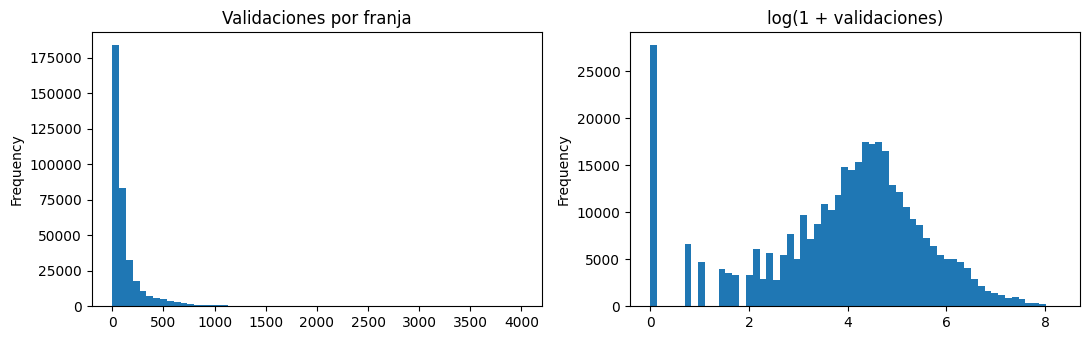

Asimetría original: 4.77 | en logaritmo: -0.68


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
datos.validaciones.plot.hist(bins=60, ax=ax[0], title="Validaciones por franja")
np.log1p(datos.validaciones).plot.hist(bins=60, ax=ax[1], title="log(1 + validaciones)")
plt.tight_layout(); plt.savefig(FIG / "distribucion_objetivo.png", dpi=120); plt.show()
print("Asimetría original: {:.2f} | en logaritmo: {:.2f}".format(
      datos.validaciones.skew(), np.log1p(datos.validaciones).skew()))

### 2.3 Variables derivadas

In [8]:
datos["hora"] = datos.franja_min / 60
datos["franja"] = datos.franja_min.apply(lambda m: f"{m // 60:02d}:{m % 60:02d}")
datos["dia_semana"] = datos.fecha.dt.dayofweek
datos["festivo"] = datos.fecha.isin(FESTIVOS).astype(int)
datos["tipo_dia"] = np.select(
    [(datos.dia_semana == 6) | (datos.festivo == 1), datos.dia_semana == 5],
    ["domingo_festivo", "sabado"], default="habil")
datos["grupo"] = datos.codigo + "|" + datos.tipo_dia                 # para splines
datos["celda"] = datos.grupo + "|" + datos.franja_min.astype(str)    # estación x tipo de día x franja
datos["celda_dia"] = (datos.codigo + "|" + datos.dia_semana.astype(str) + "|"
                      + datos.franja_min.astype(str))                # estación x día de la semana x franja
datos["y"] = np.log1p(datos.validaciones)

NUMERICAS = ["accesos"]
if oferta is not None:
    datos = datos.merge(oferta, on=["codigo", "tipo_dia", "franja_min"], how="left")
    datos[["buses", "rutas"]] = datos[["buses", "rutas"]].fillna(0)
    datos = datos.merge(ubicacion, on="codigo", how="left")
    NUMERICAS += ["buses", "rutas"]
else:
    datos["lat"], datos["lon"] = np.nan, np.nan
HAY_UBICACION = datos.lat.notna().any()

pd.DataFrame({"variable": ["hora", "dia_semana / tipo_dia / festivo", "estacion (codigo)", "accesos",
                           "buses, rutas", "lat, lon"],
              "origen": ["Excel", "Excel (fecha)", "Excel", "Excel", "GTFS", "GTFS"],
              "disponible": [True, True, True, True, oferta is not None, HAY_UBICACION]})

,variable,origen,disponible
0,hora,Excel,True
1,dia_semana / tipo_dia / festivo,Excel (fecha),True
2,estacion (codigo),Excel,True
3,accesos,Excel,True
4,"buses, rutas",GTFS,True
5,"lat, lon",GTFS,True


### 2.4 Relación con la hora y con el tipo de día (estaciones de estudio)
Esta gráfica es la evidencia principal para decidir si splines y kernels aportan.

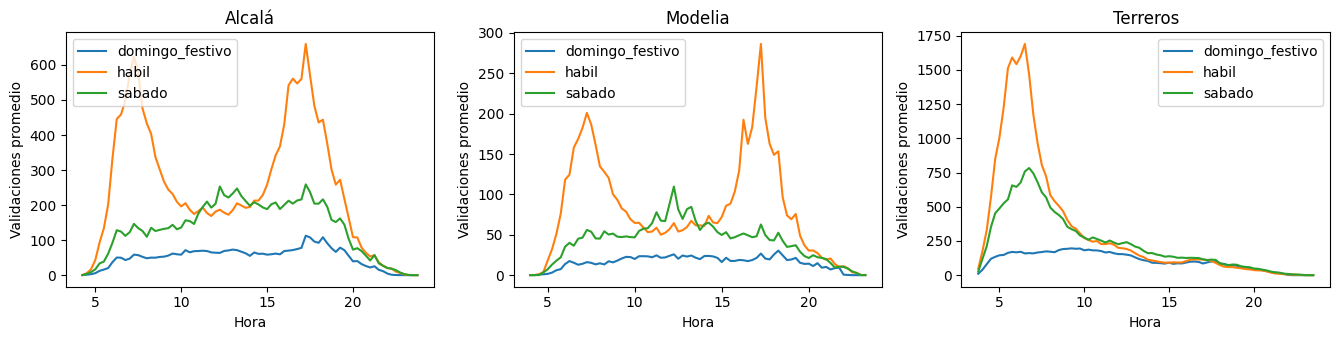

In [9]:
perfil = datos[datos.estudio].groupby(["estacion", "tipo_dia", "hora"]).validaciones.mean().reset_index()
est = [e for e in ESTUDIO.values() if e in set(perfil.estacion)]
fig, ax = plt.subplots(1, len(est), figsize=(4.5 * len(est), 3.5), squeeze=False)
for a, e in zip(ax[0], est):
    for t, g in perfil[perfil.estacion == e].groupby("tipo_dia"):
        a.plot(g.hora, g.validaciones, label=t)
    a.set_title(e); a.set_xlabel("Hora"); a.set_ylabel("Validaciones promedio"); a.legend()
plt.tight_layout(); plt.savefig(FIG / "perfil_horario.png", dpi=120); plt.show()

### 2.5 Correlaciones entre variables numéricas
Sirve para argumentar si Ridge y Lasso tienen multicolinealidad que tratar.

In [10]:
cols = ["y", "hora", "dia_semana", "festivo"] + NUMERICAS + (["lat", "lon"] if HAY_UBICACION else [])
display(datos[cols].corr().round(2))

,y,hora,dia_semana,festivo,accesos,buses,rutas,lat,lon
y,1.00,-0.21,-0.09,-0.13,0.43,0.55,0.50,0.08,-0.02
hora,-0.21,1.00,-0.00,0.00,-0.05,-0.07,0.03,0.01,0.01
dia_semana,-0.09,-0.00,1.00,-0.30,0.00,-0.17,-0.13,-0.00,-0.00
festivo,-0.13,0.00,-0.30,1.00,-0.00,-0.16,-0.16,-0.00,0.00
accesos,0.43,-0.05,0.00,-0.00,1.00,0.42,0.56,0.07,-0.04
buses,0.55,-0.07,-0.17,-0.16,0.42,1.00,0.91,0.24,0.14
rutas,0.50,0.03,-0.13,-0.16,0.56,0.91,1.00,0.25,0.13
lat,0.08,0.01,-0.00,-0.00,0.07,0.24,0.25,1.00,0.81
lon,-0.02,0.01,-0.00,0.00,-0.04,0.14,0.13,0.81,1.00


### 2.6 Decisiones de limpieza (completar y justificar)

| Decisión | Qué se hizo | Por qué |
|---|---|---|
| Filas vacías y "Total general" | Se eliminan en la carga | No son observaciones |
| Rutas duales (línea sin "Zona") | Se excluyen | Son buses en vía, no estaciones |
| Zonas | Solo AutoNorte, Calle 26 y NQS Sur | _completar_ |
| Ceros | _completar_ | _completar_ |
| Outliers | _completar_ | _completar_ |
| Transformación del objetivo | log(1 + y) | _completar con la asimetría de 2.2_ |

### 2.7 Partición entrenamiento / prueba
Se parte **por fecha**: los últimos días son la prueba. Partir al azar mezclaría el mismo día en los dos conjuntos e inflaría las métricas.

In [11]:
corte = datos.fecha.max() - pd.Timedelta(days=DIAS_TEST)
train, test = datos[datos.fecha <= corte].copy(), datos[datos.fecha > corte].copy()
X_train, y_train, grupos_train = train, train.y, train.fecha
X_test, y_test = test, test.y
print("Entrenamiento:", len(train), "registros,", train.fecha.nunique(), "días, hasta", corte.date())
print("Prueba:       ", len(test), "registros,", test.fecha.nunique(), "días |",
      "de las estaciones de estudio:", int(test.estudio.sum()))

Entrenamiento: 282609 registros, 71 días, hasta 2026-08-10
Prueba:        82509 registros, 21 días | de las estaciones de estudio: 4893


## Bloque 3. Fase 3: métodos y matriz de aplicabilidad
Todos los hiperparámetros se eligen con validación cruzada **solo sobre entrenamiento**, con los pliegues formados por fecha. Las métricas de este bloque están en escala logarítmica y sobre todas las estaciones; en el bloque 4 se pasan a pasajeros y se separan las estaciones de estudio.

### 3.0 Herramientas comunes

In [12]:
cv = GroupKFold(n_splits=min(N_FOLDS, train.fecha.nunique()))
SCORING = {"rmse": "neg_root_mean_squared_error", "mae": "neg_mean_absolute_error", "r2": "r2"}
resultados, modelos, hiper = [], {}, []

def ajustar(nombre, modelo, grid):
    """Busca hiperparámetros por validación cruzada y guarda el resultado."""
    gs = GridSearchCV(modelo, grid, cv=cv, scoring=SCORING, refit="rmse", n_jobs=-1)
    gs.fit(X_train, y_train, groups=grupos_train)
    r, i = gs.cv_results_, gs.best_index_
    resultados.append({"modelo": nombre,
                       "RMSE_cv": -r["mean_test_rmse"][i], "RMSE_sd": r["std_test_rmse"][i],
                       "MAE_cv": -r["mean_test_mae"][i], "R2_cv": r["mean_test_r2"][i]})
    for p, valores in grid.items():
        if len(valores) > 1:
            elegido = gs.best_params_[p]
            borde = elegido in (valores[0], valores[-1]) and not (p == "d" and elegido == 0)
            hiper.append({"modelo": nombre, "hiperparametro": p.split("__")[-1],
                          "rango_probado": f"{valores[0]:.4g} a {valores[-1]:.4g} ({len(valores)} valores)",
                          "elegido": elegido, "en_el_borde": borde})
            if borde:
                print(f"AVISO {nombre}: {p}={elegido} quedó en el borde del rango; ampliar la búsqueda.")
    modelos[nombre] = gs
    print(f"{nombre}: RMSE cv = {-r['mean_test_rmse'][i]:.4f} ± {r['std_test_rmse'][i]:.4f}")
    return gs

def columnas(cat, num):
    return ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), cat),
                              ("num", StandardScaler(), num)])

def columnas_estandarizadas(cat, num):
    """Variables indicadoras y numéricas, todas llevadas a la misma escala (necesario antes de regularizar)."""
    return Pipeline([("cols", ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), cat),
                                                 ("num", "passthrough", num)])),
                     ("esc", StandardScaler(with_mean=False))])

class MinimosCuadrados(BaseEstimator, RegressorMixin):
    """Regresión lineal por ecuaciones normales. Da lo mismo que LinearRegression, pero es mucho
    más rápida con la matriz dispersa de los splines."""
    def __init__(self, estabilizador=1e-8):
        self.estabilizador = estabilizador
    def fit(self, X, y):
        X, y = sparse.csr_matrix(X), np.asarray(y, dtype=float)
        n, p = X.shape
        xm, ym = np.asarray(X.mean(axis=0)).ravel(), y.mean()
        G = (X.T @ X).toarray() - n * np.outer(xm, xm)
        G[np.diag_indices(p)] += self.estabilizador * np.trace(G) / p
        self.coef_ = np.linalg.solve(G, X.T @ (y - ym))
        self.intercept_ = ym - xm @ self.coef_
        return self
    def predict(self, X):
        return X @ self.coef_ + self.intercept_

class SplinePorGrupo(BaseEstimator, TransformerMixin):
    """Base de splines de la hora, una curva distinta por grupo (estación y tipo de día)."""
    def __init__(self, n_knots=8, degree=3):
        self.n_knots, self.degree = n_knots, degree
    def fit(self, X, y=None):
        self.sp_ = SplineTransformer(n_knots=self.n_knots, degree=self.degree,
                                     extrapolation="constant").fit(X[["hora"]].to_numpy())
        self.grupos_ = {g: i for i, g in enumerate(sorted(X["grupo"].unique()))}
        return self
    def transform(self, X):
        B = self.sp_.transform(X[["hora"]].to_numpy())
        n, k = B.shape
        gi = X["grupo"].map(self.grupos_).to_numpy(dtype=float)
        ok = ~np.isnan(gi)                                   # grupos no vistos en el ajuste quedan en cero
        filas = np.repeat(np.flatnonzero(ok), k)
        cols = (gi[ok].astype(int)[:, None] * k + np.arange(k)[None, :]).ravel()
        return sparse.csr_matrix((B[ok].ravel(), (filas, cols)), shape=(n, len(self.grupos_) * k))

class KernelHoraEspacio(BaseEstimator, RegressorMixin):
    """Suavización de Nadaraya-Watson con kernel gaussiano, por tipo de día.
    h: ancho de banda en horas. d: ancho de banda en km entre estaciones (d = 0 usa solo la propia estación)."""
    def __init__(self, h=0.25, d=0.0):
        self.h, self.d = h, d
    @staticmethod
    def _km(a):
        return np.c_[a[:, 0] * 110.57, a[:, 1] * 111.32 * np.cos(np.radians(4.65))]
    def fit(self, X, y):
        t = pd.DataFrame({"codigo": X["codigo"].to_numpy(), "tipo_dia": X["tipo_dia"].to_numpy(),
                          "hora": X["hora"].to_numpy(), "y": np.asarray(y, dtype=float)})
        self.media_ = t.y.mean()
        self.est_ = np.array(sorted(t.codigo.unique()))
        self.horas_ = np.array(sorted(t.hora.unique()))
        self.xy_ = (X.drop_duplicates("codigo").set_index("codigo")[["lat", "lon"]]
                     .reindex(self.est_).to_numpy(dtype=float))
        self.sum_, self.cnt_ = {}, {}
        for td, g in t.groupby("tipo_dia"):
            p = g.groupby(["codigo", "hora"]).y.agg(["sum", "count"])
            for nombre, destino in (("sum", self.sum_), ("count", self.cnt_)):
                destino[td] = (p[nombre].unstack().reindex(index=self.est_, columns=self.horas_)
                                .fillna(0).to_numpy())
        return self
    def predict(self, X):
        out = np.full(len(X), self.media_)
        td = X["tipo_dia"].to_numpy()
        q_est, i_est = np.unique(X["codigo"].to_numpy(), return_inverse=True)
        q_h, i_h = np.unique(X["hora"].to_numpy(), return_inverse=True)
        Ws = (q_est[:, None] == self.est_[None, :]).astype(float)          # la propia estación
        if self.d > 0:
            xy = (X.drop_duplicates("codigo").set_index("codigo")[["lat", "lon"]]
                   .reindex(q_est).to_numpy(dtype=float))
            D2 = ((self._km(xy)[:, None, :] - self._km(self.xy_)[None, :, :]) ** 2).sum(-1)
            G = np.exp(-0.5 * D2 / self.d ** 2)
            Ws = np.where(np.isnan(G), Ws, G)                              # sin ubicación: solo ella misma
        Wh = np.exp(-0.5 * ((q_h[:, None] - self.horas_[None, :]) / self.h) ** 2)
        for t in np.unique(td):
            if t not in self.sum_:
                continue
            num, den = Ws @ self.sum_[t] @ Wh.T, Ws @ self.cnt_[t] @ Wh.T
            P = np.where(den > 1e-12, num / np.maximum(den, 1e-12), self.media_)
            m = td == t
            out[m] = P[i_est[m], i_h[m]]
        return out

### 3.1 Línea base: predecir la media
Referencia mínima. Un modelo que no la supere no aporta.

In [13]:
ajustar("Base (media)", DummyRegressor(strategy="mean"), {});

Base (media): RMSE cv = 1.7280 ± 0.0798


### 3.2 Regresión lineal (OLS)
Modelo de referencia: la hora entra como una recta, más estación y tipo de día.

In [14]:
ols = Pipeline([("prep", columnas(["codigo", "tipo_dia"], ["hora"] + NUMERICAS)),
                ("reg", LinearRegression())])
ajustar("OLS", ols, {});

OLS: RMSE cv = 1.0115 ± 0.2211


### 3.3 Ridge
Diseño amplio, con miles de variables indicadoras:

- una por cada combinación de estación, tipo de día y franja;
- una por cada combinación de estación, día de la semana y franja (el detalle fino, con pocas observaciones cada una);
- las numéricas.

Todas se estandarizan antes de regularizar. Se incluye el mismo diseño con OLS para que la comparación sea justa: la pregunta es si encoger los coeficientes mejora al OLS.

In [15]:
prep_amplio = columnas_estandarizadas(["celda", "celda_dia"], NUMERICAS)
print("Columnas del diseño amplio:", prep_amplio.fit_transform(X_train).shape[1])
ajustar("OLS diseño amplio", Pipeline([("prep", prep_amplio), ("reg", LinearRegression())]), {})
ajustar("Ridge", Pipeline([("prep", prep_amplio), ("reg", Ridge())]),
        {"reg__alpha": list(np.logspace(-1, 5, 7))});

Columnas del diseño amplio: 39873
OLS diseño amplio: RMSE cv = 0.5801 ± 0.3389
Ridge: RMSE cv = 0.5789 ± 0.3360


### 3.4 Lasso
Mismo diseño amplio. Además de regularizar, deja coeficientes en cero. El objetivo se centra aparte y Lasso se ajusta sin intercepto, que es equivalente y mucho más rápido con matrices dispersas.

Si el `alpha` elegido es el más pequeño del rango, Lasso se está pareciendo cada vez más al OLS: es evidencia de que anular variables **no aporta** en este problema.

In [16]:
lasso = TransformedTargetRegressor(regressor=Lasso(fit_intercept=False, max_iter=1000, tol=1e-3),
                                   transformer=StandardScaler(with_std=False))
gs_lasso = ajustar("Lasso", Pipeline([("prep", prep_amplio), ("reg", lasso)]),
                   {"reg__regressor__alpha": list(np.logspace(-4, -1, 7))})
coef = gs_lasso.best_estimator_.named_steps["reg"].regressor_.coef_
print(f"Coeficientes en cero: {(coef == 0).sum()} de {len(coef)}")

Lasso: RMSE cv = 0.5688 ± 0.3411
Coeficientes en cero: 14656 de 39873


### 3.5 Splines
Una curva suave de la hora por cada estación y tipo de día. El hiperparámetro es el número de nudos.

In [17]:
prep_sp = ColumnTransformer([("sp", SplinePorGrupo(), ["hora", "grupo"]),
                             ("cat", OneHotEncoder(handle_unknown="ignore"), ["dia_semana"]),
                             ("num", StandardScaler(), NUMERICAS)])
ajustar("Splines", Pipeline([("prep", prep_sp), ("reg", MinimosCuadrados())]),
        {"prep__sp__n_knots": [4, 8, 12, 16, 24, 32, 48]});

AVISO Splines: prep__sp__n_knots=48 quedó en el borde del rango; ampliar la búsqueda.
Splines: RMSE cv = 0.5657 ± 0.3444


### 3.6 Kernels
Suavización de Nadaraya-Watson con dos anchos de banda, cada uno en su propia unidad (por eso no hace falta estandarizar):

- `h`, en horas: cuánto se promedian las franjas vecinas.
- `d`, en kilómetros: cuánto se promedian las estaciones vecinas. `d = 0` usa solo la propia estación.

Si la validación cruzada elige `d = 0`, la parte espacial **no aporta**, y esa es una conclusión válida para la matriz.

In [18]:
grid_k = {"h": [0.05, 0.1, 0.15, 0.25, 0.4, 0.6, 1.0]}
if HAY_UBICACION:
    grid_k["d"] = [0.0, 0.5, 1.0, 2.0, 4.0]
gs_k = ajustar("Kernel (Nadaraya-Watson)", KernelHoraEspacio(), grid_k)
print("Elegidos:", gs_k.best_params_)

Kernel (Nadaraya-Watson): RMSE cv = 0.5385 ± 0.3571
Elegidos: {'d': 0.0, 'h': 0.1}


### 3.7 Resultados de validación cruzada e hiperparámetros

In [19]:
tabla_cv = pd.DataFrame(resultados).set_index("modelo").round(4).sort_values("RMSE_cv")
tabla_hiper = pd.DataFrame(hiper)
tabla_cv.to_csv(PROC / "resultados_cv.csv"); tabla_hiper.to_csv(PROC / "hiperparametros.csv", index=False)
display(tabla_cv); display(tabla_hiper)

,RMSE_cv,RMSE_sd,MAE_cv,R2_cv
modelo,,,,
Kernel (Nadaraya-Watson),0.5385,0.3571,0.3031,0.8751
Splines,0.5657,0.3444,0.3231,0.8676
Lasso,0.5688,0.3411,0.3396,0.8672
Ridge,0.5789,0.3360,0.3306,0.8642
OLS diseño amplio,0.5801,0.3389,0.3269,0.8633
OLS,1.0115,0.2211,0.7446,0.6526
Base (media),1.7280,0.0798,1.3372,-0.0023


,modelo,hiperparametro,rango_probado,elegido,en_el_borde
0,Ridge,alpha,0.1 a 1e+05 (7 valores),10000.000,False
1,Lasso,alpha,0.0001 a 0.1 (7 valores),0.001,False
2,Splines,n_knots,4 a 48 (7 valores),48.000,True
3,Kernel (Nadaraya-Watson),h,0.05 a 1 (7 valores),0.100,False
4,Kernel (Nadaraya-Watson),d,0 a 4 (5 valores),0.000,False


### 3.8 Matriz de aplicabilidad (completar con criterio propio)

| Método | ¿Aporta? | Justificación estadística | Resultado (RMSE cv) |
|---|---|---|---|
| Regresión lineal (OLS) | | | |
| Ridge | | | |
| Lasso | | | |
| Splines | | | |
| Kernels (hora) | | | |
| Kernels (espacio) | | | |

Preguntas guía: ¿la relación con la hora es una recta (2.4)? ¿Ridge mejora al OLS del mismo diseño por más que la desviación entre pliegues? ¿Cuántos coeficientes anula Lasso? ¿Splines y kernels se diferencian entre sí? ¿Qué valor de `d` eligió la validación cruzada?

## Bloque 4. Fase 4: comparación de finalistas
Los tres mejores por validación cruzada se evalúan una sola vez sobre el conjunto de prueba, en **pasajeros**: sobre todas las estaciones y sobre las de estudio. La incertidumbre se estima con bootstrap remuestreando días completos.

In [20]:
finalistas = [m for m in tabla_cv.index if not m.startswith("Base")][:3]
print("Finalistas:", finalistas)

real = test.validaciones.to_numpy()
es_estudio = test.estudio.to_numpy()
pred = {m: np.clip(np.expm1(modelos[m].predict(X_test)), 0, None) for m in finalistas + ["Base (media)"]}

def metricas(y, p):
    return {"MAE": mean_absolute_error(y, p), "RMSE": mean_squared_error(y, p) ** 0.5, "R2": r2_score(y, p)}

tabla_test = pd.concat({
    "Todas las estaciones": pd.DataFrame({m: metricas(real, p) for m, p in pred.items()}).T,
    "Estaciones de estudio": pd.DataFrame({m: metricas(real[es_estudio], p[es_estudio])
                                           for m, p in pred.items()}).T}, axis=1).round(2)
display(tabla_test)

por_estacion = pd.DataFrame({m: {e: mean_absolute_error(real[(test.estacion == e).to_numpy()],
                                                        pred[m][(test.estacion == e).to_numpy()])
                                 for e in ESTUDIO.values() if (test.estacion == e).any()}
                             for m in finalistas}).round(1)
print("Error promedio (MAE, en pasajeros por franja) en cada estación de estudio:"); display(por_estacion)

Finalistas: ['Kernel (Nadaraya-Watson)', 'Splines', 'Lasso']


Todas las estaciones                \
                                          MAE    RMSE    R2   
Kernel (Nadaraya-Watson)                33.65   77.90  0.91   
Splines                                 33.19   83.03  0.90   
Lasso                                   39.80   95.99  0.87   
Base (media)                           128.99  285.39 -0.16   

                         Estaciones de estudio                
                                           MAE    RMSE    R2  
Kernel (Nadaraya-Watson)                 44.80   89.50  0.90  
Splines                                  43.24   93.63  0.89  
Lasso                                    53.09  108.23  0.85  
Base (media)                            166.10  321.02 -0.28

Error promedio (MAE, en pasajeros por franja) en cada estación de estudio:


,Kernel (Nadaraya-Watson),Splines,Lasso
Alcalá,61.5,58.9,70.5
Modelia,15.7,16.1,16.8
Terreros,56.2,53.8,70.8


### 4.1 Bootstrap por días (estaciones de estudio)

In [22]:
rng = np.random.default_rng(SEED)
dias_test = list(test.fecha.unique())
idx_dia = [np.flatnonzero(((test.fecha == d) & test.estudio).to_numpy()) for d in dias_test]
B, boot = 500, {m: [] for m in finalistas}
for _ in range(B):
    idx = np.concatenate([idx_dia[i] for i in rng.integers(0, len(dias_test), len(dias_test))])
    for m in finalistas:
        boot[m].append(mean_absolute_error(real[idx], pred[m][idx]))
boot = pd.DataFrame(boot)

ic = boot.quantile([0.025, 0.5, 0.975]).T.round(2)
ic.columns = ["MAE_2.5%", "MAE_mediana", "MAE_97.5%"]
display(ic)
mejor = ic["MAE_mediana"].idxmin()
for m in finalistas:
    if m != mejor:
        d = (boot[m] - boot[mejor]).quantile([0.025, 0.975]).round(2).tolist()
        print(f"{m} menos {mejor}: diferencia de MAE entre {d[0]} y {d[1]}",
              "(empate)" if d[0] <= 0 <= d[1] else "(diferencia real)")
tabla_test.to_csv(PROC / "resultados_test.csv"); ic.to_csv(PROC / "bootstrap_mae.csv")
por_estacion.to_csv(PROC / "mae_por_estacion.csv")

,MAE_2.5%,MAE_mediana,MAE_97.5%
Kernel (Nadaraya-Watson),33.61,44.92,54.80
Splines,30.23,42.59,57.00
Lasso,39.79,53.01,65.92


Kernel (Nadaraya-Watson) menos Splines: diferencia de MAE entre -7.78 y 10.41 (empate)
Lasso menos Splines: diferencia de MAE entre 5.4 y 14.45 (diferencia real)


### 4.2 Real contra predicho en un día de prueba

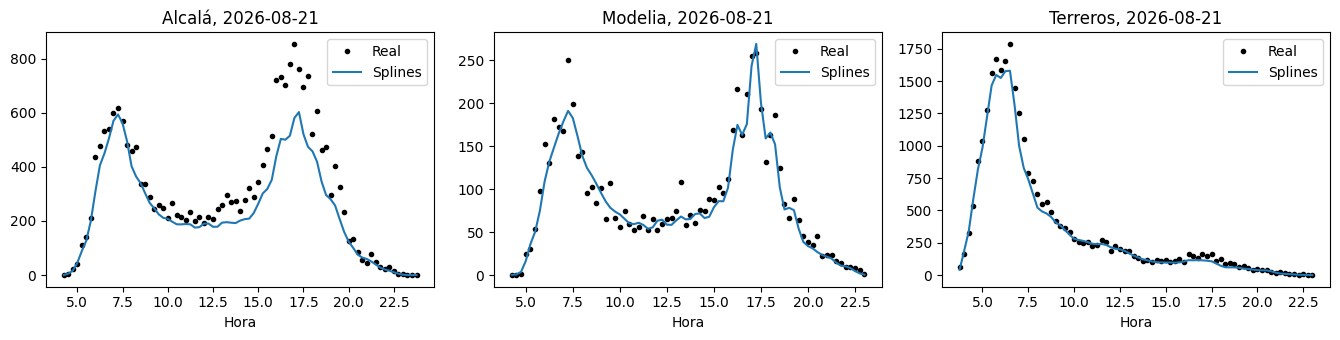

In [23]:
dia = sorted(dias_test)[len(dias_test) // 2]
est = [e for e in ESTUDIO.values() if (test.estacion == e).any()]
fig, ax = plt.subplots(1, len(est), figsize=(4.5 * len(est), 3.5), squeeze=False)
for a, e in zip(ax[0], est):
    m = ((test.fecha == dia) & (test.estacion == e)).to_numpy()
    a.plot(test.hora[m], real[m], "k.", label="Real")
    a.plot(test.hora[m], pred[mejor][m], label=mejor)
    a.set_title(f"{e}, {pd.Timestamp(dia).date()}"); a.set_xlabel("Hora"); a.legend()
plt.tight_layout(); plt.savefig(FIG / "real_vs_predicho.png", dpi=120); plt.show()

### 4.3 Decisión final (completar)

- **Ganador y por qué:** _métrica, variabilidad, interpretabilidad, costo de usarlo_.
- **¿Hubo empate dentro del margen de ruido?** _si sí, qué criterio lo desempató_.
- **Limitaciones:** _tres zonas, un trimestre, festivos, un solo horario GTFS para tres meses, oferta programada frente a la real_.

## Bloque 5. Fase 5: insumos para los informes

**Informe técnico** (`reports/informe_tecnico.md`): tablas en `data/processed/` (`resumen_carga`, `resultados_cv`, `hiperparametros`, `resultados_test`, `mae_por_estacion`, `bootstrap_mae`) y figuras en `reports/figuras/`.

**Informe gerencial** (`reports/informe_gerencial.md`): la celda siguiente traduce el error a pasajeros en cada estación de estudio y, si hay oferta, lo compara con los buses programados.

In [24]:
t_est = test[test.estudio].assign(prediccion=pred[mejor][es_estudio],
                                  error=np.abs(real - pred[mejor])[es_estudio])
resumen_g = t_est.groupby("estacion").agg(
    entradas_dia=("validaciones", lambda s: s.sum() / t_est.fecha.nunique()),
    error_promedio_por_franja=("error", "mean")).round(1)
display(resumen_g)

agg = {"esperado": ("prediccion", "mean")}
if "buses" in t_est:
    agg["buses"] = ("buses", "mean")
pico = (t_est[t_est.tipo_dia == "habil"].groupby(["estacion", "franja"]).agg(**agg)
        .reset_index().sort_values("esperado", ascending=False).groupby("estacion").head(3))
if "buses" in pico:
    pico["pasajeros_por_bus"] = (pico.esperado / pico.buses.where(pico.buses > 0)).round(0)
print("Las tres franjas de mayor demanda esperada en día hábil:"); display(pico.round(1))
resumen_g.to_csv(PROC / "resumen_gerencial.csv"); pico.to_csv(PROC / "franjas_pico.csv", index=False)

,entradas_dia,error_promedio_por_franja
estacion,,
Alcalá,17584.6,58.9
Modelia,5295.3,16.1
Terreros,22717.8,53.8


Las tres franjas de mayor demanda esperada en día hábil:


,estacion,franja,esperado,buses,pasajeros_por_bus
166,Terreros,06:30,1380.3,48.0,29.0
165,Terreros,06:15,1377.2,41.0,34.0
163,Terreros,05:45,1351.7,38.0,36.0
52,Alcalá,17:15,525.9,47.0,11.0
12,Alcalá,07:15,518.2,54.0,10.0
51,Alcalá,17:00,506.9,43.0,12.0
131,Modelia,17:15,234.6,30.0,8.0
130,Modelia,17:00,212.1,32.0,7.0
132,Modelia,17:30,174.8,31.0,6.0


### 5.1 Solo en Colab: subir tablas y figuras a GitHub
Pongan `SUBIR = True` cuando quieran guardar. El notebook se guarda aparte, con Archivo > Guardar una copia en GitHub.

In [25]:
SUBIR = False
if EN_COLAB and SUBIR:
    !git -C /content/{REPO} pull --rebase
    !git -C /content/{REPO} add data/processed reports
    !git -C /content/{REPO} commit -m "Resultados del notebook"
    !git -C /content/{REPO} push